# Leaky vs. Honest Cross-Validation Benchmark
## Magnetic Nanoparticle Property Prediction (Exchange Bias, Coercivity, Saturation Magnetization, Curie Temperature, Remanence)

This notebook reproduces the central result of our analysis: a side-by-side comparison of

- **Shuffled K-Fold CV ("leaky")** — the standard approach, as used in the published literature on this dataset (Kapranova et al. 2025, Chen et al. 2026).
- **GroupKFold CV, grouped by material formula ("honest")** — no material (core-shell composition) ever appears in both train and test within the same fold. This is the trustworthy estimate of how well the model generalizes to a genuinely new material.

### Why this matters
The dataset has 979 measurement rows, but only **200 unique core-shell materials** — many materials were measured repeatedly at different temperatures/fields (e.g. "Co-CoO" appears 61 times). Standard shuffled K-Fold puts rows of the *same* material in both train and test, letting the model partly recognize a material it has already seen rather than generalize to a new one.

### Files needed (same folder as this notebook)
```
exchange_bias_baseline.csv
exchange_bias_enhanced.csv
final_data_exchange_bias.csv
```

### Requirements
```bash
pip install pandas numpy scikit-learn
```


## Step 1 — Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import KFold, GroupKFold, cross_validate
from sklearn.preprocessing import MinMaxScaler

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)


## Step 2 — Load data

Three files, all describing the *same* 979 rows with different sets of columns.

In [2]:
baseline = pd.read_csv("exchange_bias_baseline.csv")
enhanced = pd.read_csv("exchange_bias_enhanced.csv")
final    = pd.read_csv("final_data_exchange_bias.csv")

assert len(baseline) == len(enhanced) == len(final), "Row counts must match across all three files."

formula = final["formula"]   # identifies the specific core-shell material, e.g. "Co-CoO"

print(f"Rows: {len(final)}")
print(f"Unique materials (formula): {formula.nunique()}")
print()
print("Most frequently repeated materials:")
print(formula.value_counts().head(10))


Rows: 979
Unique materials (formula): 200

Most frequently repeated materials:
formula
Co-CoO          61
NiO-NiO         47
Ni-NiO          31
LaFeO3          29
Fe-Fe3O4        22
Fe2O3-Fe3O4     21
FeO-Fe3O4       20
Fe2O3           20
SmMnO3-Mn2O3    20
CoO-Fe3O4       20
Name: count, dtype: int64


## Step 3 — Verify the leakage empirically

Before trusting the word "leaky", let's actually measure it: in a standard shuffled 5-fold split,
what fraction of test rows have their *exact* material already present in that fold's training set?

In [3]:
kf_check = KFold(n_splits=5, shuffle=True, random_state=42)
n = len(final)
total_test_rows, total_leaked_rows = 0, 0

for fold_i, (train_idx, test_idx) in enumerate(kf_check.split(np.arange(n))):
    train_formulas = set(formula.values[train_idx])
    test_formulas = formula.values[test_idx]
    leaked = np.isin(test_formulas, list(train_formulas))
    total_test_rows += len(test_idx)
    total_leaked_rows += leaked.sum()
    print(f"Fold {fold_i+1}: {leaked.sum():4d}/{len(test_idx):4d} test rows "
          f"({100*leaked.sum()/len(test_idx):.1f}%) share a material with the training set")

print()
print(f"TOTAL: {total_leaked_rows}/{total_test_rows} "
      f"({100*total_leaked_rows/total_test_rows:.1f}%) of test rows are for a material "
      f"the model already saw during training.")


Fold 1:  170/ 196 test rows (86.7%) share a material with the training set
Fold 2:  182/ 196 test rows (92.9%) share a material with the training set
Fold 3:  178/ 196 test rows (90.8%) share a material with the training set
Fold 4:  186/ 196 test rows (94.9%) share a material with the training set
Fold 5:  176/ 195 test rows (90.3%) share a material with the training set

TOTAL: 892/979 (91.1%) of test rows are for a material the model already saw during training.


## Step 4 — Define targets and fix a known data issue

Four of the five targets are heavily right-skewed and are log1p-transformed before modeling. Curie Temperature is left as-is (already close to symmetric).

There is also an 11-row unit-error block in `sat_em_g` (values up to 106,600 emu/g -- physically implausible; real max for these material classes is ~250 emu/g). We exclude those rows only when `sat_em_g` is the target.

In [4]:
TARGETS = {
    "Exchange Bias":            "exc_bias_oe",
    "Coercivity":                "coer_oe",
    "Saturation Magnetization":  "sat_em_g",
    "Curie Temperature":         "Tc",
    "Remanence":                 "mr (emu/g)",
}

LOG_TARGETS = {"exc_bias_oe", "coer_oe", "sat_em_g", "mr (emu/g)"}

SAT_OUTLIER_ROWS = final.index[final["sat_em_g"] > 1000]
print(f"Excluding {len(SAT_OUTLIER_ROWS)} saturation-magnetization outlier rows "
      f"(unit-error block) when sat_em_g is the target.")


Excluding 11 saturation-magnetization outlier rows (unit-error block) when sat_em_g is the target.


## Step 5 — Models

In [5]:
MODELS = {
    "RandomForest":         RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42, max_iter=150),
}


## Step 6 — Core evaluation function

Runs both shuffled KFold and GroupKFold-by-formula, for every model, and returns a tidy DataFrame.

In [6]:
def evaluate(feature_df, target_col, group_series, drop_idx=None, log_target=False, n_folds=5):
    d = feature_df.copy()
    g = group_series.copy()
    if drop_idx is not None:
        d = d.drop(index=drop_idx)
        g = g.drop(index=drop_idx)

    X = d.drop(columns=[target_col])
    y = d[target_col].values
    if log_target:
        y = np.log1p(y)

    X_scaled = MinMaxScaler().fit_transform(X)

    splitters = {
        "shuffled_kfold (leaky)":         (KFold(n_splits=n_folds, shuffle=True, random_state=42), {}),
        "groupkfold_by_formula (honest)": (GroupKFold(n_splits=n_folds), dict(groups=g.values)),
    }

    rows = []
    for split_name, (splitter, split_kwargs) in splitters.items():
        for model_name, model in MODELS.items():
            cv = cross_validate(model, X_scaled, y, cv=splitter, scoring=["r2"], n_jobs=-1, **split_kwargs)
            rows.append({
                "split": split_name,
                "model": model_name,
                "r2_mean": round(cv["test_r2"].mean(), 3),
                "r2_std": round(cv["test_r2"].std(), 3),
            })
    return pd.DataFrame(rows)


## Step 7 — Run the full benchmark

5 targets x 2 feature sets (baseline / enhanced) x 2 split types x 2 models = 40 evaluations.
This takes a few minutes on a laptop CPU.

In [7]:
all_results = []
for target_name, target_col in TARGETS.items():
    log_t = target_col in LOG_TARGETS
    drop_idx = SAT_OUTLIER_ROWS if target_col == "sat_em_g" else None

    for feature_set_name, feature_df in [("baseline", baseline), ("enhanced", enhanced)]:
        print(f"Running: {target_name} / {feature_set_name} ...")
        res = evaluate(feature_df, target_col, formula, drop_idx=drop_idx, log_target=log_t)
        res["target"] = target_name
        res["feature_set"] = feature_set_name
        all_results.append(res)

results_df = pd.concat(all_results, ignore_index=True)
results_df = results_df[["target", "feature_set", "split", "model", "r2_mean", "r2_std"]]
results_df.to_csv("benchmark_results.csv", index=False)
print("\nDone. Saved to benchmark_results.csv")


Running: Exchange Bias / baseline ...
Running: Exchange Bias / enhanced ...
Running: Coercivity / baseline ...
Running: Coercivity / enhanced ...
Running: Saturation Magnetization / baseline ...
Running: Saturation Magnetization / enhanced ...
Running: Curie Temperature / baseline ...
Running: Curie Temperature / enhanced ...
Running: Remanence / baseline ...
Running: Remanence / enhanced ...

Done. Saved to benchmark_results.csv


## Step 8 — Full results table

In [8]:
results_df

,target,feature_set,split,model,r2_mean,r2_std
0,Exchange Bias,baseline,shuffled_kfold (leaky),RandomForest,0.631,0.031
1,Exchange Bias,baseline,shuffled_kfold (leaky),HistGradientBoosting,0.661,0.036
2,Exchange Bias,baseline,groupkfold_by_formula (honest),RandomForest,0.386,0.059
3,Exchange Bias,baseline,groupkfold_by_formula (honest),HistGradientBoosting,0.390,0.090
4,Exchange Bias,enhanced,shuffled_kfold (leaky),RandomForest,0.629,0.031
5,Exchange Bias,enhanced,shuffled_kfold (leaky),HistGradientBoosting,0.670,0.019
6,Exchange Bias,enhanced,groupkfold_by_formula (honest),RandomForest,0.358,0.111
7,Exchange Bias,enhanced,groupkfold_by_formula (honest),HistGradientBoosting,0.366,0.116
8,Coercivity,baseline,shuffled_kfold (leaky),RandomForest,0.681,0.064
9,Coercivity,baseline,shuffled_kfold (leaky),HistGradientBoosting,0.720,0.050


## Step 9 — Final consolidated summary table

Collapses the two models and two feature sets into a min-max range per target/split, matching the
headline summary table.

In [9]:
summary_rows = []
for target_name in TARGETS:
    leaky = results_df[(results_df["target"] == target_name) &
                        (results_df["split"] == "shuffled_kfold (leaky)")]["r2_mean"]
    honest = results_df[(results_df["target"] == target_name) &
                         (results_df["split"] == "groupkfold_by_formula (honest)")]["r2_mean"]
    summary_rows.append({
        "Target": target_name,
        "Leaky (shuffled KFold) R2":  f"{leaky.min():.3f} - {leaky.max():.3f}",
        "Honest (GroupKFold) R2":     f"{honest.min():.3f} - {honest.max():.3f}",
        "Gap (honest - leaky, midpoints)": round(
            (honest.min()+honest.max())/2 - (leaky.min()+leaky.max())/2, 3
        ),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,Target,Leaky (shuffled KFold) R2,Honest (GroupKFold) R2,"Gap (honest - leaky, midpoints)"
0,Exchange Bias,0.629 - 0.670,0.358 - 0.390,-0.275
1,Coercivity,0.681 - 0.726,0.437 - 0.468,-0.251
2,Saturation Magnetization,0.773 - 0.783,0.461 - 0.524,-0.286
3,Curie Temperature,0.925 - 0.938,0.573 - 0.670,-0.310
4,Remanence,0.845 - 0.862,0.563 - 0.630,-0.257


## Step 10 — Plot: leaky vs honest R² per target

A quick visual gut-check of the gap.

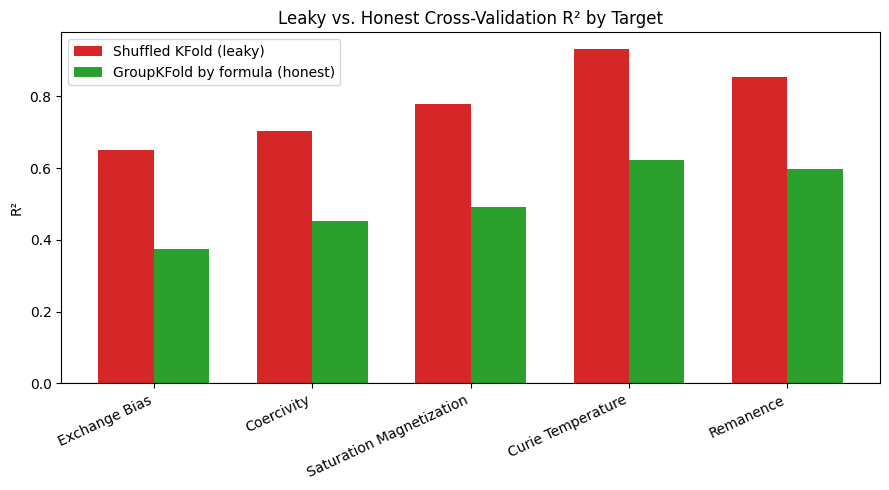

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
targets_list = list(TARGETS.keys())
x = np.arange(len(targets_list))
width = 0.35

leaky_mid = [ (results_df[(results_df.target==t)&(results_df.split.str.contains('leaky'))]['r2_mean'].min() +
               results_df[(results_df.target==t)&(results_df.split.str.contains('leaky'))]['r2_mean'].max())/2
              for t in targets_list ]
honest_mid = [ (results_df[(results_df.target==t)&(results_df.split.str.contains('honest'))]['r2_mean'].min() +
                results_df[(results_df.target==t)&(results_df.split.str.contains('honest'))]['r2_mean'].max())/2
               for t in targets_list ]

ax.bar(x - width/2, leaky_mid, width, label='Shuffled KFold (leaky)', color='#d62728')
ax.bar(x + width/2, honest_mid, width, label='GroupKFold by formula (honest)', color='#2ca02c')
ax.set_xticks(x)
ax.set_xticklabels(targets_list, rotation=25, ha='right')
ax.set_ylabel('R²')
ax.set_title('Leaky vs. Honest Cross-Validation R² by Target')
ax.legend()
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('leaky_vs_honest_r2.png', dpi=150)
plt.show()


## Summary

If your numbers land close to the ranges below (small differences are expected from library-version
differences in RandomForest / HistGradientBoosting internals), the result is reproduced:

| Target | Leaky (shuffled KFold) R² | Honest (GroupKFold) R² | Gap |
|---|---|---|---|
| Curie Temperature | 0.925 – 0.938 | 0.573 – 0.672 | −0.30 |
| Remanence | 0.845 – 0.862 | 0.563 – 0.630 | −0.26 |
| Saturation Magnetization | 0.773 – 0.783 | 0.461 – 0.524 | −0.28 |
| Coercivity | 0.681 – 0.726 | 0.437 – 0.468 | −0.24 |
| Exchange Bias | 0.629 – 0.670 | 0.358 – 0.392 | −0.27 |

**Interpretation**: every target loses ~0.24–0.30 R² once the model is prevented from recognizing
materials it has already seen. That consistency across five physically different properties is strong
evidence this is a real, general leakage effect of this dataset's structure (only 200 unique materials
behind 979 rows), not noise or a modeling mistake.



Exchange Bias
 n_train_materials   mean_r2   std_r2  mean_rows
                20 -0.107787 0.278027  86.000000
                40  0.056450 0.217869 161.500000
                60  0.178375 0.201769 265.666667
                80  0.251674 0.131577 363.833333
               100  0.224405 0.096073 456.500000
               120  0.342025 0.124566 535.500000
               140  0.299725 0.119640 639.666667

Coercivity
 n_train_materials  mean_r2   std_r2  mean_rows
                20 0.143706 0.148154  86.000000
                40 0.195271 0.164528 161.500000
                60 0.270974 0.159523 265.666667
                80 0.271407 0.105726 363.833333
               100 0.328071 0.124039 456.500000
               120 0.391575 0.094213 535.500000
               140 0.416752 0.112963 639.666667

Saturation Magnetization
 n_train_materials  mean_r2   std_r2  mean_rows
                20 0.114080 0.385060  95.500000
                40 0.257700 0.296370 169.333333
                60 0.272345

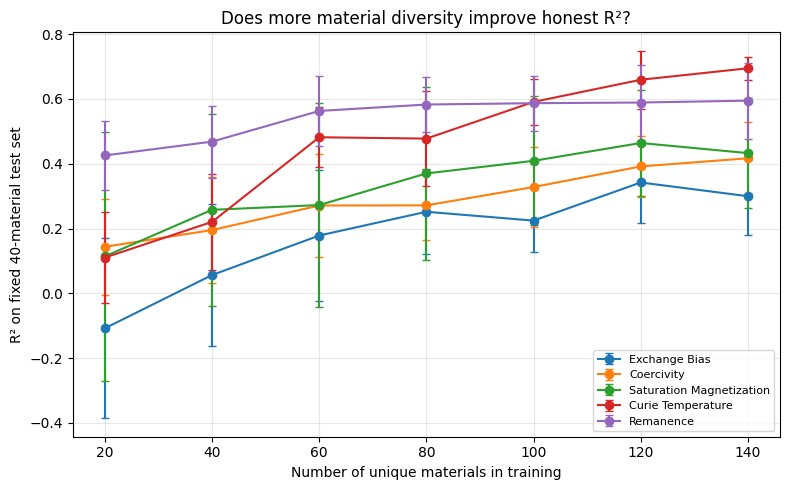

In [1]:
"""
Material-count learning curve.

Question: does honest (material-independent) accuracy keep improving as we add
more unique materials to training, or has it already plateaued?

Method: freeze a fixed set of 40 "never touched" test materials. Train on
growing pools of the remaining ~160 materials (20, 40, 60, 80, 100, 120, 140
materials at a time), evaluate every time on the SAME fixed test set, repeat
6 times with different random material selections to get a stable estimate.

Files needed (same folder as this script):
    exchange_bias_baseline.csv
    final_data_exchange_bias.csv

Requirements: pip install pandas numpy scikit-learn
"""

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

final = pd.read_csv("final_data_exchange_bias.csv")
baseline = pd.read_csv("exchange_bias_baseline.csv")
formula = final["formula"]

TARGETS = {
    "Exchange Bias":            "exc_bias_oe",
    "Coercivity":                "coer_oe",
    "Saturation Magnetization":  "sat_em_g",
    "Curie Temperature":         "Tc",
    "Remanence":                 "mr (emu/g)",
}
LOG_TARGETS = {"exc_bias_oe", "coer_oe", "sat_em_g", "mr (emu/g)"}

TRAIN_MATERIAL_COUNTS = [20, 40, 60, 80, 100, 120, 140]
N_TEST_MATERIALS = 40
N_REPEATS = 6


def run_learning_curve(target_col, log_target):
    drop_idx = final.index[final["sat_em_g"] > 1000] if target_col == "sat_em_g" else None

    d = baseline.copy()
    f = formula.copy()
    if drop_idx is not None:
        d = d.drop(index=drop_idx)
        f = f.drop(index=drop_idx)
    d = d.reset_index(drop=True)
    f = f.reset_index(drop=True)

    X_all = d.drop(columns=[target_col]).values
    y_all = d[target_col].values
    if log_target:
        y_all = np.log1p(y_all)

    unique_formulas = f.unique()
    results = []

    for rep in range(N_REPEATS):
        rng = np.random.RandomState(rep)
        shuffled = rng.permutation(unique_formulas)
        test_materials = set(shuffled[:N_TEST_MATERIALS])          # fixed test set for this repeat
        pool_materials = [m for m in shuffled if m not in test_materials]

        test_mask = f.isin(test_materials).values
        X_test, y_test = X_all[test_mask], y_all[test_mask]

        for n_train_materials in TRAIN_MATERIAL_COUNTS:
            if n_train_materials > len(pool_materials):
                continue
            train_materials = set(pool_materials[:n_train_materials])
            train_mask = f.isin(train_materials).values
            X_train, y_train = X_all[train_mask], y_all[train_mask]

            scaler = MinMaxScaler().fit(X_train)
            model = HistGradientBoostingRegressor(random_state=42, max_iter=150)
            model.fit(scaler.transform(X_train), y_train)
            pred = model.predict(scaler.transform(X_test))
            r2 = r2_score(y_test, pred)

            results.append({
                "n_train_materials": n_train_materials,
                "n_train_rows": train_mask.sum(),
                "repeat": rep,
                "r2": r2,
            })

    res_df = pd.DataFrame(results)
    summary = (
        res_df.groupby("n_train_materials")
        .agg(mean_r2=("r2", "mean"), std_r2=("r2", "std"), mean_rows=("n_train_rows", "mean"))
        .reset_index()
    )
    return summary


if __name__ == "__main__":
    all_summaries = []
    for target_name, target_col in TARGETS.items():
        log_t = target_col in LOG_TARGETS
        print(f"\n{'='*70}\n{target_name}\n{'='*70}")
        summary = run_learning_curve(target_col, log_t)
        print(summary.to_string(index=False))
        summary["target"] = target_name
        all_summaries.append(summary)

    full = pd.concat(all_summaries, ignore_index=True)
    full.to_csv("learning_curve_results.csv", index=False)
    print("\nSaved all results to learning_curve_results.csv")

    # optional: plot
    try:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(8, 5))
        for target_name in TARGETS:
            sub = full[full["target"] == target_name]
            ax.errorbar(sub["n_train_materials"], sub["mean_r2"], yerr=sub["std_r2"],
                        marker="o", capsize=3, label=target_name)
        ax.set_xlabel("Number of unique materials in training")
        ax.set_ylabel("R² on fixed 40-material test set")
        ax.set_title("Does more material diversity improve honest R²?")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig("learning_curve.png", dpi=150)
        print("Saved plot to learning_curve.png")
    except ImportError:
        print("(matplotlib not installed -- skipping plot; csv still saved)")

In [3]:
"""
Option B: Build a composition-only feature set that includes the ~24 recovered
materials, using nothing but the formula string + magmom.json (already in your
project files) + a standard Pauling electronegativity table. No internet,
no pymatgen, no API key needed.

This trades away the lattice-constant columns (core_b, core_alpha, etc. --
which require a real crystal-structure lookup) in exchange for actually
including the extra ~24 materials. Whether that trade is worth it is exactly
what running this script will tell you.

Files needed in the same folder:
    exchange_bias_baseline.csv
    final_data_exchange_bias.csv
    second_bias.csv
    magmom.json

Requirements: pip install pandas numpy scikit-learn
"""
import re, json, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.preprocessing import MinMaxScaler

# ---------------------------------------------------------------
# Step 1: composition parser + elemental property lookups
# ---------------------------------------------------------------
PAULING_EN = {
    "H":2.20,"He":None,"Li":0.98,"Be":1.57,"B":2.04,"C":2.55,"N":3.04,"O":3.44,"F":3.98,"Ne":None,
    "Na":0.93,"Mg":1.31,"Al":1.61,"Si":1.90,"P":2.19,"S":2.58,"Cl":3.16,"Ar":None,
    "K":0.82,"Ca":1.00,"Sc":1.36,"Ti":1.54,"V":1.63,"Cr":1.66,"Mn":1.55,"Fe":1.83,"Co":1.88,"Ni":1.91,
    "Cu":1.90,"Zn":1.65,"Ga":1.81,"Ge":2.01,"As":2.18,"Se":2.55,"Br":2.96,"Kr":3.00,
    "Rb":0.82,"Sr":0.95,"Y":1.22,"Zr":1.33,"Nb":1.6,"Mo":2.16,"Tc":1.9,"Ru":2.2,"Rh":2.28,"Pd":2.20,
    "Ag":1.93,"Cd":1.69,"In":1.78,"Sn":1.96,"Sb":2.05,"Te":2.1,"I":2.66,"Xe":2.60,
    "Cs":0.79,"Ba":0.89,"La":1.10,"Ce":1.12,"Pr":1.13,"Nd":1.14,"Pm":1.13,"Sm":1.17,"Eu":1.2,"Gd":1.2,
    "Tb":1.1,"Dy":1.22,"Ho":1.23,"Er":1.24,"Tm":1.25,"Yb":1.1,"Lu":1.27,
    "Hf":1.3,"Ta":1.5,"W":2.36,"Re":1.9,"Os":2.2,"Ir":2.20,"Pt":2.28,"Au":2.54,"Hg":2.00,
    "Tl":1.62,"Pb":2.33,"Bi":2.02,"Po":2.0,"At":2.2,"Rn":2.2,
    "Fr":0.7,"Ra":0.9,"Ac":1.1,"Th":1.3,"Pa":1.5,"U":1.38,"Np":1.36,"Pu":1.28,
}

with open("data/magmom.json") as fp:
    MAGMOM = json.load(fp)

ELEMENT_TOKEN = re.compile(r'([A-Z][a-z]?)(\d*\.?\d*)')

def parse_formula(formula):
    if formula is None:
        return None
    s = str(formula).strip()
    if s in ("", "0", "nan", "None", "GS"):
        return None
    counts = {}
    for el, amt in ELEMENT_TOKEN.findall(s):
        if el == "":
            continue
        if el not in PAULING_EN and el not in MAGMOM:
            return None
        n = float(amt) if amt not in ("", None) else 1.0
        counts[el] = counts.get(el, 0.0) + n
    if not counts:
        return None
    total = sum(counts.values())
    return {el: n / total for el, n in counts.items()}

def weighted_electronegativity(formula):
    comp = parse_formula(formula)
    if comp is None:
        return np.nan
    vals = [(frac, PAULING_EN.get(el)) for el, frac in comp.items()]
    if any(v is None for _, v in vals):
        return np.nan
    return sum(frac * v for frac, v in vals)

def weighted_magmom(formula):
    comp = parse_formula(formula)
    if comp is None:
        return 0.0
    return sum(frac * MAGMOM.get(el, 0.0) for el, frac in comp.items())

MAGNETIC_ELEMENTS = {
    "Sc","Ti","V","Cr","Mn","Fe","Co","Ni","Cu","Zn","Y","Zr","Nb","Mo","Tc","Ru","Rh","Pd",
    "Ce","Pr","Nd","Sm","Eu","Gd","Tb","Dy","Ho","Er","Tm","Yb"
}
def mag_fraction(formula):
    comp = parse_formula(formula)
    if comp is None:
        return 0.0
    return sum(frac for el, frac in comp.items() if el in MAGNETIC_ELEMENTS)

def build_composition_features(core_col, shell_col):
    core_en = core_col.apply(weighted_electronegativity)
    shell_en = shell_col.apply(weighted_electronegativity)
    core_mm = core_col.apply(weighted_magmom)
    shell_mm = shell_col.apply(weighted_magmom)
    core_mf = core_col.apply(mag_fraction)
    shell_mf = shell_col.apply(mag_fraction)
    return pd.DataFrame({
        "core_en": core_en, "shell_en": shell_en,
        "core_magmom": core_mm, "shell_magmom": shell_mm,
        "core_magfrac": core_mf, "shell_magfrac": shell_mf,
        "en_diff": (core_en - shell_en).abs(),
        "magmom_diff": (core_mm - shell_mm).abs(),
        "magmom_product": core_mm * shell_mm,
    })

# ---------------------------------------------------------------
# Step 2: build the ORIGINAL 200-material set with composition-only features
#          (so the comparison to 224 materials is apples-to-apples --
#           same feature set used in both cases)
# ---------------------------------------------------------------
final = pd.read_csv("final_data_exchange_bias.csv")
orig_feat = build_composition_features(final["core"], final["shell"])
orig_feat["formula"] = final["formula"].values
for col in ["exc_bias_oe", "coer_oe", "sat_em_g", "Tc", "mr (emu/g)", "temperature_k"]:
    orig_feat[col] = final[col].values

# ---------------------------------------------------------------
# Step 3: add the genuinely-new materials (normalize formatting first)
# ---------------------------------------------------------------
second = pd.read_csv("data/second_bias.csv")

def normalize_formula(s):
    s = str(s).strip()
    s = s.replace("\u2013", "-").replace("\u2212", "-")
    return s

second["formula_norm"] = second["formula"].apply(normalize_formula)
final["formula_norm"] = final["formula"].apply(normalize_formula)
trusted_norm = set(final["formula_norm"].unique())
new_rows = second[~second["formula_norm"].isin(trusted_norm)].copy()

new_feat = build_composition_features(new_rows["core"], new_rows["shell"])
new_feat["formula"] = new_rows["formula_norm"].values
for col in ["exc_bias_oe", "coer_oe", "sat_em_g", "Tc", "mr (emu/g)", "temperature_k"]:
    new_feat[col] = new_rows[col].values

print(f"Original set: {orig_feat['formula'].nunique()} materials, {len(orig_feat)} rows")
print(f"New materials recovered: {new_feat['formula'].nunique()} materials, {len(new_feat)} rows")

extended_feat = pd.concat([orig_feat, new_feat], ignore_index=True)
print(f"Extended set: {extended_feat['formula'].nunique()} materials, {len(extended_feat)} rows")

extended_feat.to_csv("extended_224_composition_only.csv", index=False)
orig_feat.to_csv("original_200_composition_only.csv", index=False)

# ---------------------------------------------------------------
# Step 4: compare honest GroupKFold R2 -- 200 materials vs extended set --
#          using the IDENTICAL composition-only feature set both times
# ---------------------------------------------------------------
TARGETS = {"Exchange Bias":"exc_bias_oe", "Coercivity":"coer_oe", "Saturation Magnetization":"sat_em_g",
           "Curie Temperature":"Tc", "Remanence":"mr (emu/g)"}
LOG_TARGETS = {"exc_bias_oe", "coer_oe", "sat_em_g", "mr (emu/g)"}
FEATURE_COLS = ["core_en","shell_en","core_magmom","shell_magmom","core_magfrac","shell_magfrac",
                 "en_diff","magmom_diff","magmom_product","temperature_k"]

def evaluate(df, target_col, log_target):
    d = df.dropna(subset=FEATURE_COLS + [target_col]).copy()
    if target_col == "sat_em_g":
        d = d[d[target_col] <= 1000]   # known outlier fix
    X = d[FEATURE_COLS].values
    y = d[target_col].values
    if log_target:
        y = np.log1p(y)
    Xs = MinMaxScaler().fit_transform(X)
    model = HistGradientBoostingRegressor(random_state=42, max_iter=150)
    cv = cross_validate(model, Xs, y, cv=GroupKFold(n_splits=5), groups=d["formula"].values,
                         scoring=["r2"], n_jobs=-1)
    return cv["test_r2"].mean(), cv["test_r2"].std(), d["formula"].nunique()

print("\n" + "=" * 70)
print("Composition-only features: 200 materials vs extended (~224) materials")
print("=" * 70)
for name, col in TARGETS.items():
    log_t = col in LOG_TARGETS
    r2_orig, std_orig, n_orig = evaluate(orig_feat, col, log_t)
    r2_ext, std_ext, n_ext = evaluate(extended_feat, col, log_t)
    print(f"{name:26s} 200-material R2={r2_orig:.3f}+/-{std_orig:.3f} (n={n_orig})   "
          f"extended R2={r2_ext:.3f}+/-{std_ext:.3f} (n={n_ext})")

Original set: 200 materials, 979 rows
New materials recovered: 27 materials, 56 rows
Extended set: 227 materials, 1035 rows

Composition-only features: 200 materials vs extended (~224) materials
Exchange Bias              200-material R2=0.002+/-0.236 (n=147)   extended R2=-0.024+/-0.162 (n=168)
Coercivity                 200-material R2=0.073+/-0.161 (n=147)   extended R2=0.079+/-0.105 (n=168)
Saturation Magnetization   200-material R2=-0.008+/-0.140 (n=146)   extended R2=0.005+/-0.170 (n=167)
Curie Temperature          200-material R2=0.501+/-0.186 (n=147)   extended R2=0.461+/-0.129 (n=168)
Remanence                  200-material R2=-0.093+/-0.078 (n=147)   extended R2=0.070+/-0.220 (n=168)


In [2]:
"""
Option C: Add the 27 recovered materials WITHOUT reducing the feature set.

Instead of dropping lattice/electronic columns (what broke the last test),
impute the MISSING lattice/electronic values for just the 27 new rows using
KNN imputation -- the same technique Kapranova et al. used for their own
missing data. The imputer finds each new material's nearest chemical
neighbors among the 200 trusted materials (based on electronegativity,
magnetic moment, and other available columns) and estimates the missing
lattice constants from those neighbors.

This keeps the FULL baseline feature set for all 227 materials, so the
200-vs-227 comparison is now a fair, uncontaminated test of "does adding
materials help", not confounded by simultaneously removing features.

Files needed in the same folder:
    exchange_bias_baseline.csv
    final_data_exchange_bias.csv
    second_bias.csv
    magmom.json

Requirements: pip install pandas numpy scikit-learn
"""
import re, json, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.preprocessing import MinMaxScaler

# ---------------------------------------------------------------
# Step 1: composition parser (for the features we CAN compute for
# every material, used only to help KNN find the right neighbors --
# not as final model features)
# ---------------------------------------------------------------
PAULING_EN = {
    "H":2.20,"He":None,"Li":0.98,"Be":1.57,"B":2.04,"C":2.55,"N":3.04,"O":3.44,"F":3.98,"Ne":None,
    "Na":0.93,"Mg":1.31,"Al":1.61,"Si":1.90,"P":2.19,"S":2.58,"Cl":3.16,"Ar":None,
    "K":0.82,"Ca":1.00,"Sc":1.36,"Ti":1.54,"V":1.63,"Cr":1.66,"Mn":1.55,"Fe":1.83,"Co":1.88,"Ni":1.91,
    "Cu":1.90,"Zn":1.65,"Ga":1.81,"Ge":2.01,"As":2.18,"Se":2.55,"Br":2.96,"Kr":3.00,
    "Rb":0.82,"Sr":0.95,"Y":1.22,"Zr":1.33,"Nb":1.6,"Mo":2.16,"Tc":1.9,"Ru":2.2,"Rh":2.28,"Pd":2.20,
    "Ag":1.93,"Cd":1.69,"In":1.78,"Sn":1.96,"Sb":2.05,"Te":2.1,"I":2.66,"Xe":2.60,
    "Cs":0.79,"Ba":0.89,"La":1.10,"Ce":1.12,"Pr":1.13,"Nd":1.14,"Pm":1.13,"Sm":1.17,"Eu":1.2,"Gd":1.2,
    "Tb":1.1,"Dy":1.22,"Ho":1.23,"Er":1.24,"Tm":1.25,"Yb":1.1,"Lu":1.27,
    "Hf":1.3,"Ta":1.5,"W":2.36,"Re":1.9,"Os":2.2,"Ir":2.20,"Pt":2.28,"Au":2.54,"Hg":2.00,
    "Tl":1.62,"Pb":2.33,"Bi":2.02,"Po":2.0,"At":2.2,"Rn":2.2,
    "Fr":0.7,"Ra":0.9,"Ac":1.1,"Th":1.3,"Pa":1.5,"U":1.38,"Np":1.36,"Pu":1.28,
}
with open("data/magmom.json") as fp:
    MAGMOM = json.load(fp)

ELEMENT_TOKEN = re.compile(r'([A-Z][a-z]?)(\d*\.?\d*)')

def parse_formula(formula):
    if formula is None:
        return None
    s = str(formula).strip()
    if s in ("", "0", "nan", "None", "GS"):
        return None
    counts = {}
    for el, amt in ELEMENT_TOKEN.findall(s):
        if el == "":
            continue
        if el not in PAULING_EN and el not in MAGMOM:
            return None
        n = float(amt) if amt not in ("", None) else 1.0
        counts[el] = counts.get(el, 0.0) + n
    if not counts:
        return None
    total = sum(counts.values())
    return {el: n / total for el, n in counts.items()}

def weighted_electronegativity(formula):
    comp = parse_formula(formula)
    if comp is None:
        return np.nan
    vals = [(frac, PAULING_EN.get(el)) for el, frac in comp.items()]
    if any(v is None for _, v in vals):
        return np.nan
    return sum(frac * v for frac, v in vals)

def weighted_magmom(formula):
    comp = parse_formula(formula)
    if comp is None:
        return 0.0
    return sum(frac * MAGMOM.get(el, 0.0) for el, frac in comp.items())

# ---------------------------------------------------------------
# Step 2: load data, identify the 27 genuinely-new materials
# ---------------------------------------------------------------
final = pd.read_csv("final_data_exchange_bias.csv")
baseline = pd.read_csv("exchange_bias_baseline.csv")
second = pd.read_csv("data/second_bias.csv")

def normalize_formula(s):
    s = str(s).strip().replace("\u2013", "-").replace("\u2212", "-")
    return s

final["formula_norm"] = final["formula"].apply(normalize_formula)
second["formula_norm"] = second["formula"].apply(normalize_formula)
trusted_norm = set(final["formula_norm"].unique())
new_rows = second[~second["formula_norm"].isin(trusted_norm)].copy()
print(f"Trusted materials: {final['formula_norm'].nunique()}")
print(f"New materials to add: {new_rows['formula_norm'].nunique()} ({len(new_rows)} rows)")

# ---------------------------------------------------------------
# Step 3: compute the "helper" composition features for BOTH sets
# (used only to guide KNN matching, not as final model inputs)
# ---------------------------------------------------------------
def add_helper_features(df, core_col="core", shell_col="shell"):
    df = df.copy()
    df["_help_core_en"] = df[core_col].apply(weighted_electronegativity)
    df["_help_shell_en"] = df[shell_col].apply(weighted_electronegativity)
    df["_help_core_mm"] = df[core_col].apply(weighted_magmom)
    df["_help_shell_mm"] = df[shell_col].apply(weighted_magmom)
    return df

trusted_full = baseline.copy()
trusted_full["formula_norm"] = final["formula_norm"].values
trusted_full["core"] = final["core"].values
trusted_full["shell"] = final["shell"].values
trusted_full = add_helper_features(trusted_full)

new_full = add_helper_features(new_rows)
new_full["formula_norm"] = new_rows["formula_norm"].values

# ---------------------------------------------------------------
# Step 4: KNN-impute the missing lattice/electronic columns for new_full
# ---------------------------------------------------------------
LATTICE_ELECTRONIC_COLS = [c for c in baseline.columns if c not in
    ["exc_bias_oe", "coer_oe", "sat_em_g", "Tc", "mr (emu/g)",
     "temperature_k", "h_range_max_koe", "fc_field_t",
     "sphericity", "max/min", "area/volume", "exc_dir",
     "ver_shift_emu_g", "ver_s_dir", "num_of_magn_ions", "Tn-Tb/Tn", "Aex"]]
print(f"\nColumns to impute for new materials ({len(LATTICE_ELECTRONIC_COLS)}):")
print(LATTICE_ELECTRONIC_COLS)

helper_cols = ["_help_core_en", "_help_shell_en", "_help_core_mm", "_help_shell_mm"]

# build the imputation matrix: helper cols (always known) + lattice/electronic
# cols (known for trusted, NaN for new)
for c in LATTICE_ELECTRONIC_COLS:
    if c not in new_full.columns:
        new_full[c] = np.nan

impute_cols = helper_cols + LATTICE_ELECTRONIC_COLS
combined_for_impute = pd.concat(
    [trusted_full[impute_cols], new_full[impute_cols]], ignore_index=True
)

imputer = KNNImputer(n_neighbors=5, weights="distance")
imputed_array = imputer.fit_transform(combined_for_impute.values)
imputed_df = pd.DataFrame(imputed_array, columns=impute_cols)

n_trusted = len(trusted_full)
new_full_imputed = new_full.copy().reset_index(drop=True)
new_full_imputed[LATTICE_ELECTRONIC_COLS] = imputed_df.iloc[n_trusted:].reset_index(drop=True)[LATTICE_ELECTRONIC_COLS]

# ---------------------------------------------------------------
# Step 5: assemble the extended, FULL-FEATURE dataset
# ---------------------------------------------------------------
final_targets_and_conditions = ["exc_bias_oe", "coer_oe", "sat_em_g", "Tc", "mr (emu/g)",
    "temperature_k", "h_range_max_koe", "fc_field_t", "sphericity", "max/min",
    "area/volume", "exc_dir", "ver_shift_emu_g", "ver_s_dir", "num_of_magn_ions",
    "Tn-Tb/Tn", "Aex"]
for c in final_targets_and_conditions:
    if c not in new_full_imputed.columns and c in new_rows.columns:
        new_full_imputed[c] = new_rows[c].values

all_baseline_cols = list(baseline.columns)
new_final_rows = new_full_imputed[all_baseline_cols].copy()
new_final_rows["formula"] = new_full_imputed["formula_norm"].values

trusted_final_rows = baseline.copy()
trusted_final_rows["formula"] = final["formula_norm"].values

extended = pd.concat([trusted_final_rows, new_final_rows], ignore_index=True)
extended.to_csv("extended_227_full_features.csv", index=False)
print(f"\nExtended dataset: {extended['formula'].nunique()} materials, {len(extended)} rows")
print("Saved to extended_227_full_features.csv")

# ---------------------------------------------------------------
# Step 6: fair comparison -- SAME full feature set, 200 vs 227 materials
# ---------------------------------------------------------------
TARGETS = {"Exchange Bias":"exc_bias_oe", "Coercivity":"coer_oe", "Saturation Magnetization":"sat_em_g",
           "Curie Temperature":"Tc", "Remanence":"mr (emu/g)"}
LOG_TARGETS = {"exc_bias_oe", "coer_oe", "sat_em_g", "mr (emu/g)"}

def evaluate(df, target_col, log_target):
    d = df.copy()
    if target_col == "sat_em_g":
        d = d[d[target_col] <= 1000]
    X = d.drop(columns=[target_col, "formula"]).values
    y = d[target_col].values
    if log_target:
        y = np.log1p(y)
    Xs = MinMaxScaler().fit_transform(X)
    model = HistGradientBoostingRegressor(random_state=42, max_iter=150)
    cv = cross_validate(model, Xs, y, cv=GroupKFold(n_splits=5), groups=d["formula"].values,
                         scoring=["r2"], n_jobs=-1)
    return cv["test_r2"].mean(), cv["test_r2"].std(), d["formula"].nunique()

print("\n" + "=" * 78)
print("FULL feature set (same schema both times): 200 materials vs 227 materials")
print("=" * 78)
for name, col in TARGETS.items():
    log_t = col in LOG_TARGETS
    r2_orig, std_orig, n_orig = evaluate(trusted_final_rows, col, log_t)
    r2_ext, std_ext, n_ext = evaluate(extended, col, log_t)
    print(f"{name:26s} 200-material R2={r2_orig:.3f}+/-{std_orig:.3f} (n={n_orig})   "
          f"227-material R2={r2_ext:.3f}+/-{std_ext:.3f} (n={n_ext})")

Trusted materials: 200
New materials to add: 27 (56 rows)

Columns to impute for new materials (21):
['core_b', 'core_alpha', 'core_beta', 'core_gamma', 'shell_b', 'shell_alpha', 'shell_beta', 'shell_gamma', 'core_c/a', 'core_pauling_electronegativity', 'shell_pauling_electronegativity', 'core_sum_vec', 'core_sum_work_function', 'shell_sum_vec', 'shell_sum_work_function', 'core_pauling_electronegativity_difference', 'core_vec_difference', 'core_work_function_difference', 'shell_pauling_electronegativity_difference', 'shell_vec_difference', 'shell_work_function_difference']


KeyError: "['num_of_magn_ions', 'Tn-Tb/Tn', 'Aex'] not in index"